# Big Data Platforms — Why We Need Scalable Cloud Platforms

**A study notebook based on Lecture 1 of *Big Data Platforms* (DATA140031 / DATA140032), University of Helsinki, by Keijo Heljanko.**

> This notebook is an expanded, self-contained, runnable companion to the original slide deck (`lecture1.pdf`, included in this repo under `slides/`). Lecture 1 is the "why" lecture: before we ever touch MapReduce or Spark (that's [Lecture 2](../lecture2/Big_Data_Platforms_Lecture2.ipynb)), we need to understand *why* a single fast computer stopped being enough, and *why* the industry moved to warehouse-scale, fault-tolerant, horizontally-scaled clusters instead.

**How to use this notebook**
- Read top to bottom — sections build on each other, exactly like the lecture.
- Code cells are real, executable Python (plots reproducing / extending the lecture's key quantitative arguments — Amdahl's Law, hardware latency numbers, the word-search parallelism example).
- Diagrams and photos are the original figures from the slides, extracted as images so nothing visual is lost.

**Contents**
1. [Course overview](#1) *(brief — logistics, not examinable content)*
2. [What is cloud computing?](#2)
3. [Business drivers of the cloud](#3)
4. [Why single machines stopped getting faster](#4)
5. [Amdahl's Law](#5)
6. [Scaling up vs. scaling out](#6)
7. [Warehouse-Scale Computing (WSC)](#7)
8. [Rule-of-thumb latency numbers every engineer should know](#8)
9. [At warehouse scale, failure is the norm](#9)
10. [Big Data: how much, and from where?](#10)
11. [Worked example: parallel word search](#11)
12. [Summary & where this leads](#12)


<a id="1"></a>
## 1. Course overview

*(This section only summarizes the administrative content of the lecture — course structure, not technical material. Feel free to skip straight to [Section 2](#2) if you're reading this as a technical reference rather than as a student on the actual course.)*

- **Course:** DATA140031 (MOOC, 3 ECTS) + DATA140032 (MOOC EXAM, 2 ECTS), University of Helsinki.
- **Format:** DATA140031 is pass/fail, free of charge, graded purely on automatically-graded **Apache PySpark** home exercises (≥ 60% required), done in a Docker-based PySpark JupyterHub environment. Basic Python and SQL are prerequisites. **Use of LLM-based tools (e.g. ChatGPT) is prohibited** for the home exercises.
- DATA140032 is the graded (0–5) exam version, covering both the lectures and the home assignments, subject to Open University fees for non-University-of-Helsinki students.
- **Lectures:** delivered live on Zoom, with slides and a recording released within ~48 hours.
- **No single textbook** — the course is built from the lecture slides plus recommended supplementary readings (which is exactly what these notebooks are turning into a fuller reference).

The two courses can be combined for University of Helsinki students' CS / Data Science major studies, provided both are passed.


<a id="2"></a>
## 2. What is cloud computing?

The lecture anchors the definition in the standard reference:

> **The NIST Definition of Cloud Computing** — Peter Mell and Tim Grance, NIST Special Publication 800-145. <https://csrc.nist.gov/publications/detail/sp/800-145/final>

> *"Cloud computing is a model for enabling convenient, on-demand network access to a shared pool of configurable computing resources (e.g., networks, servers, storage, applications, and services) that can be rapidly provisioned and released with minimal management effort or service provider interaction."*

NIST breaks this down into **5 essential characteristics**, **3 service models**, and **4 deployment models**:

| Category | Items |
|---|---|
| **Essential characteristics** | On-demand self-service · Broad network access · Resource pooling · Rapid elasticity · Measured service |
| **Service models** | **SaaS** (Software as a Service) · **PaaS** (Platform as a Service) · **IaaS** (Infrastructure as a Service) |
| **Deployment models** | Private cloud · Community cloud · Public cloud · Hybrid cloud |

**Why this matters for this course:** "Big Data Platforms" are, in NIST's language, mostly **PaaS/IaaS-level scalable batch processing, storage, and datastore technologies** — the layer that sits between raw virtualized infrastructure and the end-user application. A rough map of where the tools we'll study fit into the cloud stack:

| Layer | Example technologies (from the lecture) |
|---|---|
| Virtualization of compute | Amazon EC2 & EKS, Microsoft Azure, Google Cloud Platform, OpenStack Compute, Kubernetes |
| Scalable file storage | Amazon S3, Google File System (GFS), Hadoop Distributed File System (HDFS) |
| Scalable batch processing | Google MapReduce / Apache Hadoop, Apache Flink, **Apache Spark** ← this course's main focus |
| Scalable datastore | Amazon Dynamo, Apache Cassandra, Riak, Google Bigtable, HBase, Chubby, Apache ZooKeeper |
| Scalable web app hosting | Google App Engine, Microsoft Azure, Heroku |


<a id="3"></a>
## 3. Business drivers of the cloud

Why did the industry converge on giant, centralized data centers instead of everyone running their own server room? The lecture gives a simple **economics of scale** argument: building at massive scale makes almost every input cheaper.

- **Cheaper hardware purchases** — buying components by the tens of thousands gives enormous negotiating leverage.
- **Cheaper cooling** — a striking real example from the lecture: **Google paid €40 million for a former Summa paper mill site in Hamina, Finland**, specifically because it could be cooled with sea water pumped straight from the Baltic Sea, instead of building energy-hungry mechanical chillers.
- **Cheaper electricity** — large operators can site data centers where power is cheap and negotiate bulk rates.
- **Cheaper network capacity** and **fewer administrators per computer** — operational overhead per machine shrinks dramatically with scale.

The flip side of buying at that scale: you can no longer afford (or even find) enough *reliable* enterprise-grade hardware. The solution is architectural, not mechanical:

> **Unreliable, commodity hardware is used. Reliability is obtained by replicating hardware components, combined with a fault-tolerant *software* stack.**

This one sentence is the thesis of the entire course: *if the hardware is going to fail routinely, tolerate it in software instead of trying to eliminate it in hardware.* Everything from HDFS's block replication to Spark's RDD lineage-based recovery ([see Lecture 2](../Big_Data_Platforms_Lecture2.ipynb)) is a direct consequence of this design philosophy.

### A real example: Google's Hamina data center

The former Summa paper mill in Hamina, Finland is a good concrete anchor for "economics of scale" — repurposed industrial infrastructure, cooled by the sea instead of chillers, and now one of Google's flagship data centers.

![Google Summa Warehouse Scale Computer, seen from outside in winter](../images/google_summa_wsc.png)

![Google Summa data center from the roof level](../images/google_summa_roof.png)

**The sea-water cooling system** — pumps and pipework that move Baltic Sea water through the facility to remove heat without energy-intensive mechanical refrigeration:

![Google Summa sea water cooling infrastructure](../images/google_summa_sea_water_cooling.png)

**Inside the computer hall** — this is what "a warehouse full of computers" actually looks like:

![Google Summa computer hall, rows of server racks](../images/google_summa_computer_hall.png)


<a id="4"></a>
## 4. Why single machines stopped getting faster

To understand why Big Data platforms exist at all, we need one more piece of context: for decades, software got faster "for free" just by waiting for next year's CPU. That free lunch ended, and the reasons matter for how we're now forced to write software.

### Moore's Law (transistor counts) — still going

**Gordon Moore, Intel, 1965:** the number of transistors on an integrated circuit chip doubles roughly every 18–24 months. This has, remarkably, held up for over 50 years:

![Moore's Law: transistor counts 1971–2018 (Our World in Data)](../images/moores_law.png)

### But clock speed stalled around 2004–2005

More transistors used to directly mean *higher clock speeds*, which meant every single-threaded program got faster automatically. That stopped:

![Intel CPU trends: transistors, clock speed, power, and performance/clock (Sutter, 2005/2009)](../images/clock_speed_processors.png)

> **Herb Sutter**, *"The Free Lunch Is Over: A Fundamental Turn Toward Concurrency in Software"*, Dr. Dobb's Journal, 30(3), March 2005 (chart updated August 2009).

Notice in the chart above: **clock speed (MHz)** and **power (W)** both plateau hard after the mid-2000s, while **transistor count** keeps climbing. Those extra transistors had to go *somewhere* — and where they went was **more cores per chip**, not faster individual cores.

### The consequence, in single-threaded performance numbers

Zooming out to a longer, more recent timeline of *single-threaded* performance (relative to a 1978 VAX-11/780) makes the slowdown even clearer — note the shrinking annual growth rate written directly on the chart: **52%/year → 23%/year → 12%/year → 9%/year**:

![Single-threaded performance improvements, 1978–2022 (Hennessy & Patterson)](../images/single_threaded_performance.png)

> J. Hennessy, D. Patterson — *Computer Architecture: A Quantitative Approach*, 7th ed., 2026.

### Implications

- Clock speeds aren't going to meaningfully improve — single-threaded performance gains from here on are **moderate at best**.
- Transistor counts are *still* growing fast — but that budget is now spent almost entirely on **adding more cores**, not making one core faster.
- **Programming models must change** to actually exploit all this available concurrency. Scalability to a high (and ever-growing) number of cores/processors has to become a first-class design goal — which is exactly the gap that MapReduce and Spark are built to fill.

### Dark Silicon: an even harder wall ahead

There's a further complication: **power**. Silicon is becoming energy-constrained — soon we will have *more transistors than we can actually switch on simultaneously at full clock speed* without overheating the chip. Idle, powered-down transistor area is termed **"Dark Silicon."**

> Hadi Esmaeilzadeh, Emily R. Blem, Renée St. Amant, Karthikeyan Sankaralingam, Doug Burger — *"Dark Silicon and the End of Multicore Scaling"*, IEEE Micro 32(3): 122-134 (2012).
>
> Michael B. Taylor — *"A Landscape of the New Dark Silicon Design Regime"*, IEEE Micro 33(5): 8-19 (2013).

The industry's response has been **specialized hardware**: GPGPU computing has driven big energy-efficiency gains for training deep neural networks, and purpose-built ASICs (like **Google's Tensor Processing Units**) specifically accelerate neural-network *inference*. Expect similar special-purpose accelerators to spread well beyond machine learning.


<a id="5"></a>
## 5. Amdahl's Law

If chips are only getting *more cores*, not *faster cores*, the obvious question is: can't we just always throw more cores at any problem? **Amdahl's Law** is the classic, sobering answer: **no — not unless your program is almost entirely parallelizable.**

**Statement:** if $P$ is the proportion of a program that *can* be parallelized, and $(1-P)$ is the proportion that must remain strictly serial, then the maximum possible speedup achievable using $N$ processors is:

$$\text{Speedup}(N) = \frac{1}{(1-P) + \frac{P}{N}}$$

Reference: <http://en.wikipedia.org/wiki/Amdahl%27s_law>

The original lecture includes Wikipedia's classic illustrative chart:

![Amdahl's Law example chart from Wikipedia — speedup vs. number of processors for various parallel fractions](../images/amdahls_law_wikipedia_example.png)

Let's not just look at that chart — let's **reproduce it ourselves** from the formula, and see exactly why it looks the way it does.

Matplotlib is building the font cache; this may take a moment.


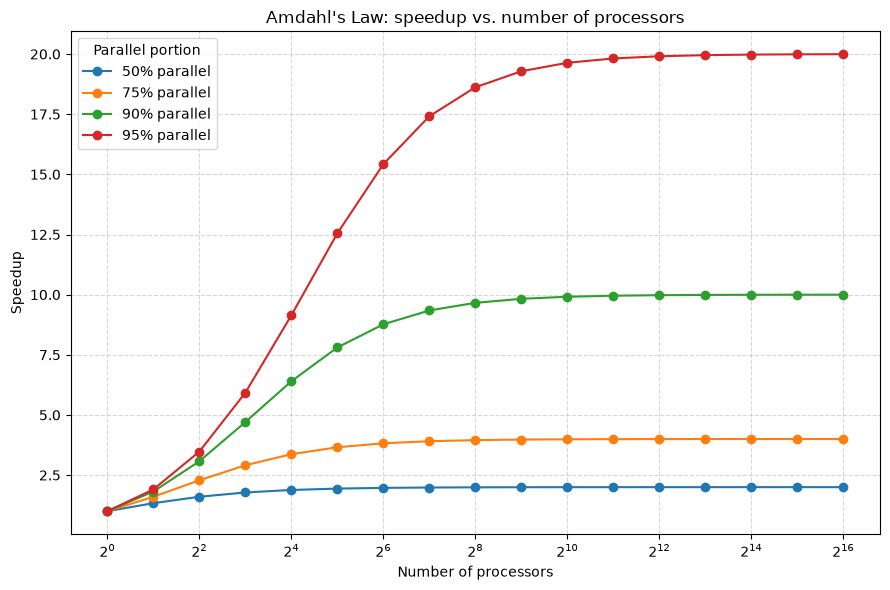

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def amdahl_speedup(P, N):
    """Maximum theoretical speedup with N processors, P = parallelizable fraction."""
    return 1.0 / ((1 - P) + P / N)

N = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256, 512,
              1024, 2048, 4096, 8192, 16384, 32768, 65536])

parallel_fractions = [0.50, 0.75, 0.90, 0.95]

plt.figure(figsize=(9, 6))
for P in parallel_fractions:
    plt.plot(N, amdahl_speedup(P, N), marker='o', label=f"{int(P*100)}% parallel")

plt.xscale('log', base=2)
plt.xlabel("Number of processors")
plt.ylabel("Speedup")
plt.title("Amdahl's Law: speedup vs. number of processors")
plt.legend(title="Parallel portion")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Reading this chart, the same way the lecture's Wikipedia figure is meant to be read:

- Every curve **flattens out at a hard ceiling**, no matter how many processors you throw at it. That ceiling is exactly $\frac{1}{1-P}$ — e.g. at 90% parallel, the absolute best you can ever do, even with infinite processors, is a **10×** speedup.
- Even the most favourable curve here (95% parallel) tops out at **20×** — you'd need to push into the high hundreds/thousands of cores before you're even close to that ceiling, and it barely moves after that.
- **The practical lesson for Big Data platforms:** getting real speedups at the scale of thousands of machines is only possible if the *serial* fraction of your algorithm is squeezed to something extremely close to zero. This is precisely why MapReduce and Spark are built around embarrassingly-parallel primitives (`map`, `filter`, independent partition processing) and treat any unavoidable synchronization (the `shuffle`) as the expensive, carefully-minimised exception rather than the rule — see [Lecture 2, Section 9](../lecture2/Big_Data_Platforms_Lecture2.ipynb#9) on narrow vs. wide dependencies.

Let's confirm the ceiling numerically:

In [2]:
for P in parallel_fractions:
    ceiling = 1 / (1 - P)
    at_64 = amdahl_speedup(P, 64)
    at_65536 = amdahl_speedup(P, 65536)
    print(f"P={P:.2f}  |  speedup@64 cores = {at_64:5.2f}x  "
          f"|  speedup@65536 cores = {at_65536:6.2f}x  |  theoretical ceiling = {ceiling:5.1f}x")

P=0.50  |  speedup@64 cores =  1.97x  |  speedup@65536 cores =   2.00x  |  theoretical ceiling =   2.0x
P=0.75  |  speedup@64 cores =  3.82x  |  speedup@65536 cores =   4.00x  |  theoretical ceiling =   4.0x
P=0.90  |  speedup@64 cores =  8.77x  |  speedup@65536 cores =  10.00x  |  theoretical ceiling =  10.0x
P=0.95  |  speedup@64 cores = 15.42x  |  speedup@65536 cores =  19.99x  |  theoretical ceiling =  20.0x


<a id="6"></a>
## 6. Scaling up vs. scaling out

Given that you need parallelism, there are still two very different ways to get it:

| | **Scaling up** | **Scaling out** |
|---|---|---|
| **Approach** | One (very) powerful computer: more CPU cores, more memory, more disks | Many less powerful, cheaper machines, working together |
| **Cost** | More expensive per unit of CPU/memory/disk — high-end systems carry a steep price premium | Cheaper per unit — commodity hardware |
| **Fault tolerance** | Simpler — fewer components to fail | Harder — many more components (nodes + network links) means more frequent failures |
| **Software complexity** | Lower — largely still "normal" single-machine programming | Higher — must explicitly handle node failures, network partitions, and higher latencies between nodes |

**Big Data platforms deliberately choose to scale out, not up.** That choice is *why* fault tolerance and distributed-systems complexity are central, unavoidable themes of this whole course, rather than a corner case — and it's exactly the trade-off Section 3's "unreliable commodity hardware + fault-tolerant software stack" argument was setting up.


<a id="7"></a>
## 7. Warehouse-Scale Computing (WSC)

At Google's scale, the lecture makes a striking claim about what the *actual* unit of computation has become:

> *"The smallest unit of computation in Google scale is: a Warehouse full of computers."*

**Reference:** Luiz André Barroso, Urs Hölzle, Parthasarathy Ranganathan — *"The Datacenter as a Computer: Designing Warehouse-Scale Machines"*, 4th edition. <https://dx.doi.org/10.1007/978-3-031-99489-0>

> *"...we must treat the datacenter itself as one massive warehouse-scale computer (WSC)."*

In other words: don't think of a data center as "a room full of separate servers" — think of it as *a single giant computer*, where individual servers play the role that a CPU core, or even just an ALU, plays inside an ordinary desktop machine. This reframing is what justifies applying classic computer-architecture thinking (memory hierarchies, latency/bandwidth trade-offs, interconnects) to an entire building.

### Elements of a WSC

The basic building blocks, scaling up from a single server to a full cluster of racks connected by a switch fabric:

![Typical elements in a Warehouse-Scale Computer — server, rack, and racks connected via a cluster switch](../images/elements_of_wsc.png)

A real example — a row of Google servers from 2012:

![A row of servers from Google, 2012](images/google_wsc_2012_servers.png)

### A "classical" (pre-hyperscale) data center

For contrast, here's the traditional enterprise data-center design this whole approach is moving away from — full of dedicated, specialised subsystems (CRAC cooling units, UPS systems, diesel generators, fuel tanks) built for individual co-location cabinets:

![A classical data center, with CRAC, PDU, UPS, and generator subsystems labelled](../images/classical_datacenter.png)

And its classical hot-aisle/cold-aisle cooling airflow pattern:

![A classical cooling system: airflow between racks and CRAC units](../images/classical_cooling_system.png)

### Where does the power actually go?

A power breakdown for a typical two-socket server (2012 data) shows that **CPUs alone account for 42%** of a server's power draw, with cooling overhead (15.4%) as the second-largest single slice:

![Power usage breakdown for two-socket servers](../images/power_usage_breakdown.png)

This is exactly why energy-efficient cooling approaches (like Hamina's sea water, Section 3) and energy-efficient compute (Section 4's GPGPUs / TPUs) both matter so much at this scale — a huge fraction of the electricity bill isn't even doing useful computation.

### The storage hierarchy of a WSC

Just like a single CPU has L1/L2 cache → local DRAM → local disk, a WSC has its *own* much bigger hierarchy: one server → a rack of ~40 servers → a full cluster of ~125 racks. Each level trades off capacity against latency and bandwidth:

![Storage hierarchy of a WSC: server, rack, and cluster levels with DRAM/disk/flash capacity and latency figures](../images/storage_hierarchy_wsc.png)

Visualized as latency / bandwidth / capacity curves across that same hierarchy (log scale) — note how **capacity climbs steadily** while **bandwidth stays roughly flat** and **latency has a much bumpier, less predictable shape** as you move from local DRAM out to datacenter-wide disk:

![WSC latency, bandwidth, and capacity across the storage hierarchy](../images/wsc_latency_bandwidth_capacity.png)

**Why this matters for Spark:** this is the *exact same* hierarchy that motivates keeping RDDs cached in local DRAM whenever possible ([Lecture 2, Section 5](../Big_Data_Platforms_Lecture2.ipynb#5)) instead of always reading from cluster-wide disk — the numbers above show *why* that's such a big deal: DRAM access is orders of magnitude faster and lower-latency than disk, at every level of this hierarchy.


<a id="8"></a>
## 8. Rule-of-thumb latency numbers every engineer should know

A justly famous table from Google's Jeffrey Dean, from his LADIS 2009 keynote *"Designs, Lessons and Advice from Building Large Distributed Systems"* (<http://www.cs.cornell.edu/projects/ladis2009/talks/dean-keynote-ladis2009.pdf>). These numbers have been re-used in countless systems talks since, precisely because they so starkly quantify *why* naive distributed algorithms (e.g. "just do a network round trip inside your inner loop") are catastrophically slow compared to local memory access.

Let's put the whole table into code and actually visualize the scale of the gap — the numbers span **9 orders of magnitude**, so a log scale is essential.

In [3]:
latency_numbers_ns = {
    "L1 cache reference":                    0.5,
    "Branch mispredict":                       5,
    "L2 cache reference":                      7,
    "Mutex lock/unlock":                      25,
    "Main memory reference":                 100,
    "Compress 1KB with Zippy":              3_000,
    "Send 2KB over 1Gbps network":         20_000,
    "Read 1MB sequentially from memory": 250_000,
    "Round trip within same datacenter": 500_000,
    "Disk seek":                       10_000_000,
    "Read 1MB sequentially from disk": 20_000_000,
    "Send packet CA -> Netherlands -> CA": 150_000_000,
}

for name, ns in latency_numbers_ns.items():
    print(f"{name:<38} {ns:>15,.1f} ns")

L1 cache reference                                 0.5 ns
Branch mispredict                                  5.0 ns
L2 cache reference                                 7.0 ns
Mutex lock/unlock                                 25.0 ns
Main memory reference                            100.0 ns
Compress 1KB with Zippy                        3,000.0 ns
Send 2KB over 1Gbps network                   20,000.0 ns
Read 1MB sequentially from memory            250,000.0 ns
Round trip within same datacenter            500,000.0 ns
Disk seek                                 10,000,000.0 ns
Read 1MB sequentially from disk           20,000,000.0 ns
Send packet CA -> Netherlands -> CA      150,000,000.0 ns


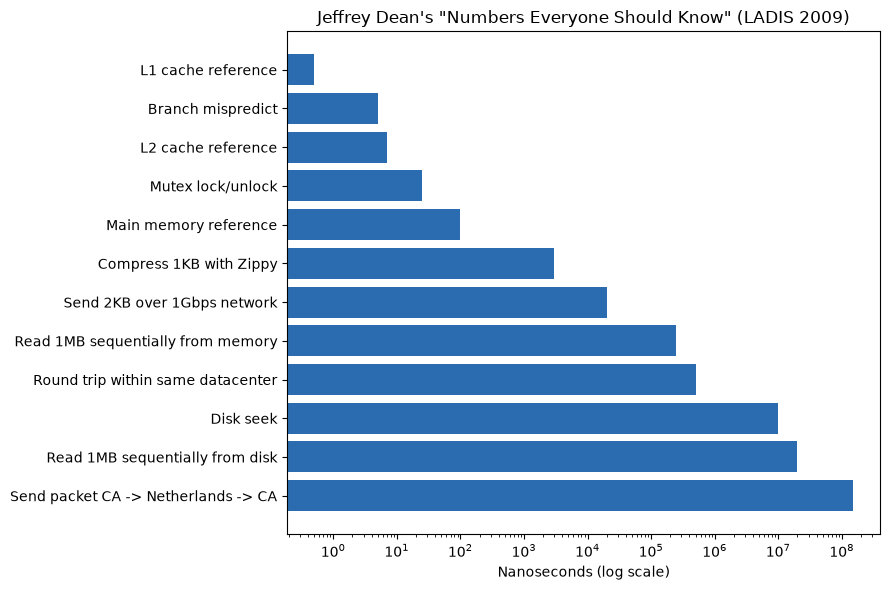

In [4]:
import matplotlib.pyplot as plt

names = list(latency_numbers_ns.keys())
values = list(latency_numbers_ns.values())

plt.figure(figsize=(9, 6))
plt.barh(names[::-1], values[::-1], color="#2b6cb0")
plt.xscale('log')
plt.xlabel("Nanoseconds (log scale)")
plt.title("Jeffrey Dean's \"Numbers Everyone Should Know\" (LADIS 2009)")
plt.tight_layout()
plt.show()

**The single most important comparison in that chart:** a **main memory reference (100 ns)** vs. a **disk seek (10,000,000 ns)** — disk is roughly **100,000× slower** than RAM. And a round trip *within the same datacenter* (500,000 ns = 0.5 ms) is already **5,000× slower** than a main memory reference, before you've even left the building.

This single comparison is the quantitative backbone of almost every design decision in this course:
- Why Spark tries to **keep data in memory** and minimise disk round-trips (Lecture 2).
- Why the **shuffle** (network movement of data between nodes) is treated as the expensive operation to minimize, not something to do casually inside a tight loop.
- Why sending a packet across an ocean and back (**150,000,000 ns = 150 ms**) is treated as an extreme, rare cost to be avoided in the hot path of any latency-sensitive distributed system.


<a id="9"></a>
## 9. At warehouse scale, failure is the norm

If you only have one server, "my server crashed" is a rare, annoying event. If you have **10,000 servers**, the arithmetic changes completely — and this is the crux of why *all* Big Data platforms are built assuming failure is a constant background process, not an edge case.

### A back-of-envelope calculation

Suppose (very optimistically — real numbers are worse) each server has a **mean time between failures (MTBF) of 30 years**. In a cluster of 10,000 nodes:

In [5]:
mtbf_years = 30
num_nodes = 10_000

# Expected failures per year across the whole cluster, assuming each
# node independently fails on average once every mtbf_years years.
failures_per_year = num_nodes / mtbf_years
failures_per_day = failures_per_year / 365

print(f"Expected node failures per year across the cluster: {failures_per_year:,.1f}")
print(f"Expected node failures per day across the cluster:  {failures_per_day:,.2f}")

Expected node failures per year across the cluster: 333.3
Expected node failures per day across the cluster:  0.91


...which comes out to **roughly one node failing per day**, even under a wildly optimistic 30-year MTBF assumption. Jeffrey Dean's real (2009) yearly flakiness metrics are considerably worse than this toy estimate:

- **1–5% of disk drives will die** every year.
- **Servers will crash at least twice** a year each (2–4% failure rate).

### "Joys of real hardware" — a typical first year for a new cluster (verbatim from Dean's talk)

| Event | Frequency & impact |
|---|---|
| Overheating | ≈0.5× — powers down most machines in < 5 min, ≈1–2 days to recover |
| PDU (power distribution unit) failure | ≈1× — 500–1000 machines suddenly disappear, ≈6 hours to return |
| Rack move | ≈1× — planned, 500–1000 machines powered down for ≈6 hours |
| Network rewiring | ≈1× — rolling ≈5% of machines down over a 2-day span |
| Rack failures | ≈20× — 40–80 machines instantly disappear, 1–6 hours to recover |
| Racks "go wonky" | ≈5× — 40–80 machines see 50% packet loss |
| Network maintenance events | ≈8× — ~4 of these may cause ≈30-minute random connectivity losses |
| Router reloads | ≈12× — takes out DNS and external VIPs for a couple of minutes |
| Router failures | ≈3× — traffic must be pulled immediately for an hour |
| Minor DNS blips | dozens, ≈30 seconds each |
| Individual machine failures | ≈1,000× |
| Hard drive failures / bad memory / misconfigured or flaky machines | thousands |
| Long-distance link disruptions | wild dogs, sharks, dead horses, drunken hunters chewing through or damaging cables (yes — literally) |

**The takeaway is not "buy better hardware."** At this scale, no realistic hardware quality improvement makes these numbers go away — the only workable strategy is **software that assumes failure is constant and routes around it automatically**: replicated storage (HDFS), automatic task re-execution (MapReduce/Spark), and leader-election / consensus services (ZooKeeper, Chubby) to keep the rest of the system consistent while individual pieces come and go.


<a id="10"></a>
## 10. Big Data: how much, and from where?

- **IDC estimates the "Global Datasphere" at 221 zettabytes in 2026** (that's 221,000,000,000 TB), projected to grow to **700 zettabytes by 2030**.
- Sources: video, digital images, sensor data, biological data, web/social media, the Internet of Things, and — increasingly — **generative AI**.
- Concrete examples from the lecture:
  - **Netflix** collects on the order of **1 PB of data per month** just from video-service user-behaviour logs.
  - **Rovio** (makers of *Angry Birds*) was collecting on the order of **1 TB of game-log data per day**.

This scale of data — far too large to fit on, or even be read sequentially by, a single machine in reasonable time — is precisely what the term **"Big Data"** refers to, and is the reason genuinely new processing approaches (rather than just "buy a bigger server") are required.


<a id="11"></a>
## 11. Worked example: parallel word search

The lecture closes its motivation with a concrete, appealingly simple arithmetic example, worth reproducing in code so the "hard disk parallelism" argument is fully tangible rather than just asserted.

**Problem:** search for a word that occurs exactly once, somewhere inside **2 TB of text**, using a compute cluster.

In [6]:
data_size_gb = 2 * 1024        # 2 TB, in GB
single_disk_read_speed_mb_s = 100   # 100 MB/s, as stated in the lecture

seconds_single_disk = (data_size_gb * 1024) / single_disk_read_speed_mb_s
hours_single_disk = seconds_single_disk / 3600

print(f"Worst-case time to scan all 2TB from a SINGLE disk: "
      f"{seconds_single_disk:,.0f} s  (~{hours_single_disk:.2f} hours)")

Worst-case time to scan all 2TB from a SINGLE disk: 20,972 s  (~5.83 hours)


That matches the lecture's stated **≈5.5 hours** worst case for a single 2 TB disk at 100 MB/s. Now let's parallelize across many disks and see how the time drops:

   1 disks in parallel ->   349.53 minutes
   2 disks in parallel ->   174.76 minutes
   5 disks in parallel ->    69.91 minutes
  10 disks in parallel ->    34.95 minutes
  20 disks in parallel ->    17.48 minutes
  50 disks in parallel ->     6.99 minutes
 100 disks in parallel ->     3.50 minutes
 200 disks in parallel ->     1.75 minutes
 500 disks in parallel ->     0.70 minutes


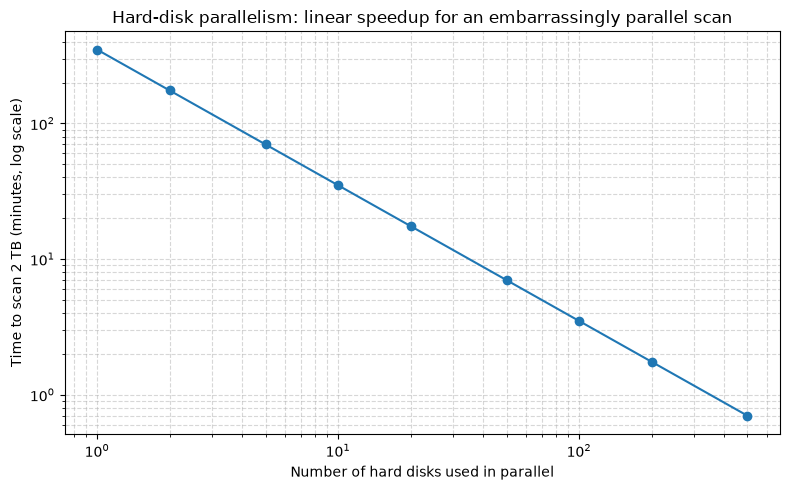

In [7]:
import matplotlib.pyplot as plt

disk_counts = [1, 2, 5, 10, 20, 50, 100, 200, 500]
minutes_needed = [seconds_single_disk / n / 60 for n in disk_counts]

for n, m in zip(disk_counts, minutes_needed):
    print(f"{n:>4} disks in parallel -> {m:8.2f} minutes")

plt.figure(figsize=(8, 5))
plt.plot(disk_counts, minutes_needed, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Number of hard disks used in parallel")
plt.ylabel("Time to scan 2 TB (minutes, log scale)")
plt.title("Hard-disk parallelism: linear speedup for an embarrassingly parallel scan")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

At **100 disks in parallel**, the same worst-case scan drops to **under 4 minutes** — matching the lecture's claim exactly.

Why does this scale essentially *perfectly linearly* (100 disks → ~100× speedup), when Section 5 just showed us that Amdahl's Law usually stops speedups from scaling that cleanly? Because **scanning independent chunks of a file for a keyword is an embarrassingly parallel problem** — there's no shared state, no coordination, and no serial bottleneck between the disks; each one just reads its own chunk and checks it independently. In Amdahl's Law terms, this task's parallel fraction $P$ is essentially **1.0**. This is exactly the shape of computation the **Map** phase of MapReduce is designed around — see [Lecture 2, Section 2](../lecture2/Big_Data_Platforms_Lecture2.ipynb#2).


<a id="12"></a>
## 12. Summary & where this leads

**The one-paragraph version of this whole lecture:**

> Single-CPU performance stopped improving in the mid-2000s (clock speeds plateaued, and Amdahl's Law limits how much any one program can benefit from the extra cores that keep arriving instead). At the same time, the sheer *volume* of data being generated (zettabytes and counting) has outgrown what any single machine could store or process. The industry's answer on both fronts is the same: **scale out** across huge numbers of cheap, individually unreliable commodity machines, organized into **warehouse-scale computers**, accepting that hardware failure becomes a routine, constant background event — and pushing all the responsibility for tolerating that failure into the **software** stack instead. Understanding *that* trade-off is the prerequisite for understanding *why* MapReduce and Apache Spark are built the way they are, which is where [Lecture 2](../lecture2/Big_Data_Platforms_Lecture2.ipynb) picks up.

### Sources referenced in this lecture

- Peter Mell, Tim Grance — [*The NIST Definition of Cloud Computing*](https://csrc.nist.gov/publications/detail/sp/800-145/final), NIST SP 800-145.
- Herb Sutter — *"The Free Lunch Is Over: A Fundamental Turn Toward Concurrency in Software"*, Dr. Dobb's Journal, 30(3), March 2005.
- John Hennessy, David Patterson — *Computer Architecture: A Quantitative Approach*, 7th ed., 2026.
- Hadi Esmaeilzadeh et al. — *"Dark Silicon and the End of Multicore Scaling"*, IEEE Micro 32(3): 122-134 (2012).
- Michael B. Taylor — *"A Landscape of the New Dark Silicon Design Regime"*, IEEE Micro 33(5): 8-19 (2013).
- [Amdahl's Law — Wikipedia](http://en.wikipedia.org/wiki/Amdahl%27s_law).
- Luiz André Barroso, Urs Hölzle, Parthasarathy Ranganathan — [*The Datacenter as a Computer: Designing Warehouse-Scale Machines*](https://dx.doi.org/10.1007/978-3-031-99489-0), 4th ed.
- Jeffrey Dean — [*"Designs, Lessons and Advice from Building Large Distributed Systems"*](http://www.cs.cornell.edu/projects/ladis2009/talks/dean-keynote-ladis2009.pdf), LADIS 2009 keynote.
- IDC — Global Datasphere estimates (2026 / 2030 projections).

### Suggested next steps

- Continue to [Lecture 2 — MapReduce & Apache Spark](../lecture2/Big_Data_Platforms_Lecture2.ipynb), which builds directly on the "scale out, tolerate failure in software" thesis established here.
- Re-run the Amdahl's Law code in Section 5 with your own estimate of the parallel fraction of a real algorithm you work with, to get an intuition for how much parallel hardware would actually be worth acquiring for it.
- Compare Jeffrey Dean's 2009 latency numbers (Section 8) against current SSD/NVMe and datacenter-network figures — many of the *relative* gaps have shrunk significantly since 2009, which is itself an interesting exercise in how quickly "well-known" systems folklore can go stale.
